# Analyse exploratoire des données (EDA) — Churn Prediction

Ce notebook a pour objectif de **comprendre le dataset** avant la modélisation :

- structure des données,
- valeurs manquantes,
- distribution de la cible `churn`,
- analyse des variables importantes,
- relations simples entre les variables et le churn,
- premières interprétations métier.


## 1. Imports et configuration

Ce notebook d’analyse exploratoire a pour objectif de comprendre la structure du dataset, d’identifier les premières relations entre variables et churn, et de construire une intuition métier avant la modélisation. L’EDA permet également de vérifier la qualité des données et de repérer les signaux les plus prometteurs pour la prédiction.

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

TARGET = "churn"

FEATURES = [
    "gender",
    "age",
    "tenure_months",
    "contract_type",
    "monthly_logins",
    "weekly_active_days",
    "avg_session_time",
    "monthly_fee",
    "payment_failures",
    "nps_score",
]

## 2. Chargement des données

In [58]:
df = pd.read_csv("../SOURCE/dataset.csv")

print(df.shape)
display(df.head())

(10000, 32)


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


## 3. Vue générale

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  object 
 1   gender                  10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  object 
 4   city                    10000 non-null  object 
 5   customer_segment        10000 non-null  object 
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  object 
 8   contract_type           10000 non-null  object 
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null 

Le dataset contient 10 000 observations et 32 variables. Il s’agit donc d’un volume suffisant pour mener une analyse exploratoire pertinente et entraîner plusieurs modèles supervisés. La diversité des variables permet d’explorer à la fois des dimensions comportementales, contractuelles et financières.

In [62]:
display(df.describe(include="all").T.head(15))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,10000,10000,CUST_00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,10000,2,Male,5013,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,10000.0,NaN,NaN,NaN,45.9061,16.420416,18.0,32.0,46.0,60.0,74.0
country,10000,7,Bangladesh,1494,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,10000,7,London,1518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,10000,3,Individual,5984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,10000.0,NaN,NaN,NaN,30.1557,17.099517,1.0,16.0,30.0,45.0,59.0
signup_channel,10000,3,Web,5036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract_type,10000,3,Monthly,4967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_logins,10000.0,NaN,NaN,NaN,19.672,9.838003,0.0,13.0,20.0,26.0,54.0


## 4. Valeurs manquantes

In [67]:
missing_percent = df.isna().mean()*100
missing_percent[missing_percent > 0].sort_values(ascending=False)

complaint_type    20.45
dtype: float64

L’analyse des valeurs manquantes montre qu’une seule variable ressort nettement : `complaint_type`. Les autres variables sont globalement complètes. Cette observation est importante, car elle indique que le dataset est globalement propre et que les efforts de traitement peuvent être concentrés sur quelques colonnes spécifiques.

## 5. Analyse de la variable cible

Taux de churn global : 10.21%


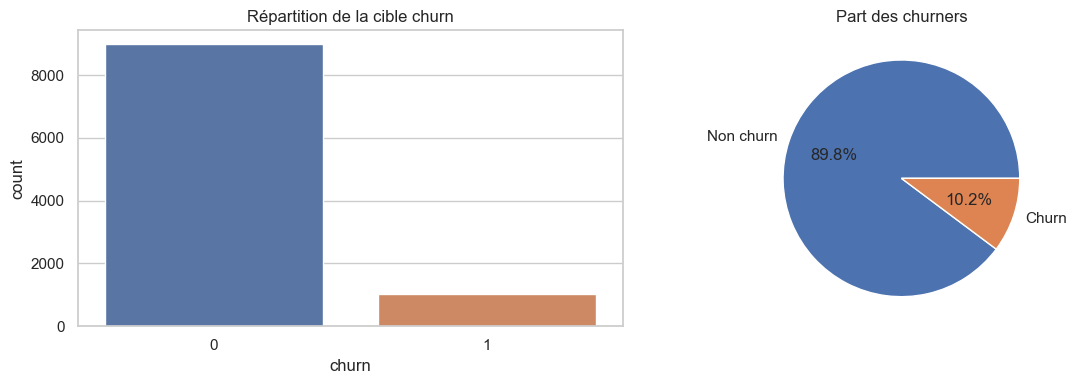

In [71]:
churn_rate = df[TARGET].mean()
print(f"Taux de churn global : {churn_rate:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x=TARGET, ax=axes[0])
axes[0].set_title("Répartition de la cible churn")

pd.Series({
    "Non churn": 1 - churn_rate,
    "Churn": churn_rate,
}).plot(kind="pie", autopct="%1.1f%%", ax=axes[1])
axes[1].set_ylabel("")
axes[1].set_title("Part des churners")

plt.tight_layout()
plt.show()


La classe positive `churn = 1` représente environ 10,21 % du dataset. Le problème est donc déséquilibré : la majorité des clients ne quitte pas. Ce point confirme qu’il serait trompeur d’évaluer les modèles uniquement avec l’accuracy. Une attention particulière devra être portée au recall, à la precision, au F1-score et à la PR-AUC.

## 6. Focus sur les variables retenues pour le modèle final

In [75]:
model_df = df[FEATURES + [TARGET]].copy()
display(model_df.head())

,gender,age,tenure_months,contract_type,monthly_logins,weekly_active_days,avg_session_time,monthly_fee,payment_failures,nps_score,churn
0,Male,68,22,Monthly,26,7,11.762372,30,1,27,0
1,Female,57,9,Monthly,7,5,26.846390,30,1,-19,1
2,Male,24,58,Yearly,19,5,23.380065,20,2,80,0
3,Male,49,19,Yearly,34,7,24.243136,30,0,100,0
4,Male,65,52,Monthly,20,6,18.872323,50,0,21,0


Pour garantir la cohérence entre l’analyse, l’entraînement, l’API et le dashboard, la modélisation finale repose sur 10 variables sélectionnées. Ce choix simplifie l’architecture du projet tout en conservant des indicateurs comportementaux et contractuels plausiblement liés au churn.

## 7. Séparer les variables numériques et catégorielles

In [78]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Variables numériques :", list(numeric_cols))
print("Variables catégorielles :", list(categorical_cols))

Variables numériques : ['age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count', 'churn']
Variables catégorielles : ['customer_id', 'gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']


Le genre et le type de contrat semblent avoir un effet relativement limité sur le churn dans ce dataset réduit à 10 variables. Les taux observés restent proches d’une catégorie à l’autre : environ 10,11 % pour les femmes contre 10,31 % pour les hommes, et entre 9,93 % et 10,34 % selon le type de contrat. Ces variables peuvent contribuer au modèle, mais elles ne semblent pas constituer à elles seules des signaux forts.

## 9. Analyse de quelques facteurs de risque métier

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

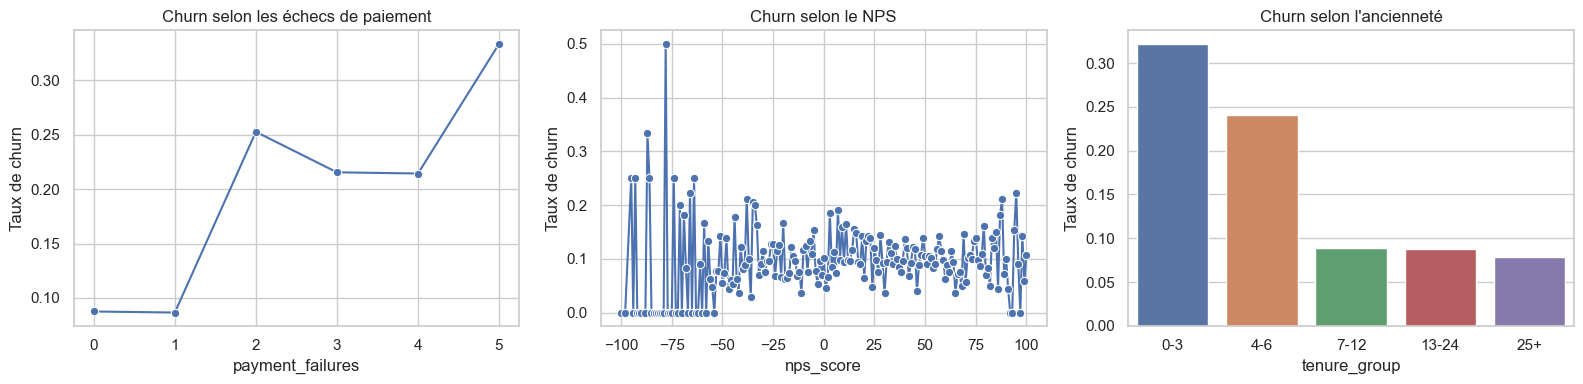

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# payment_failures
payment_churn = model_df.groupby("payment_failures")[TARGET].mean().reset_index()
sns.lineplot(data=payment_churn, x="payment_failures", y=TARGET, marker="o", ax=axes[0])
axes[0].set_title("Churn selon les échecs de paiement")
axes[0].set_ylabel("Taux de churn")

# nps_score
nps_churn = model_df.groupby("nps_score")[TARGET].mean().reset_index()
sns.lineplot(data=nps_churn, x="nps_score", y=TARGET, marker="o", ax=axes[1])
axes[1].set_title("Churn selon le NPS")
axes[1].set_ylabel("Taux de churn")

# tenure_months (buckets)
tenure_df = model_df.copy()
tenure_df["tenure_group"] = pd.cut(
    tenure_df["tenure_months"],
    bins=[-1, 3, 6, 12, 24, 60],
    labels=["0-3", "4-6", "7-12", "13-24", "25+"]
)
tenure_churn = tenure_df.groupby("tenure_group", observed=False)[TARGET].mean().reset_index()
sns.barplot(data=tenure_churn, x="tenure_group", y=TARGET, ax=axes[2])
axes[2].set_title("Churn selon l'ancienneté")
axes[2].set_ylabel("Taux de churn")

plt.tight_layout()
plt.show()

Plusieurs tendances métier intéressantes apparaissent. D’abord, les churners présentent en moyenne davantage d’échecs de paiement que les non-churners (0,74 contre 0,47), ce qui suggère qu’une friction financière peut être un signal d’alerte. Ensuite, l’ancienneté joue un rôle très net : les clients récents churnent beaucoup plus que les clients fidèles, avec un taux d’environ 32,12 % pour les 0–3 mois contre 7,83 % pour les clients de plus de 25 mois. Enfin, le score NPS apparaît ici moins discriminant que prévu, du moins dans cette sélection de variables.

## 10. Comparaison des distributions selon churn

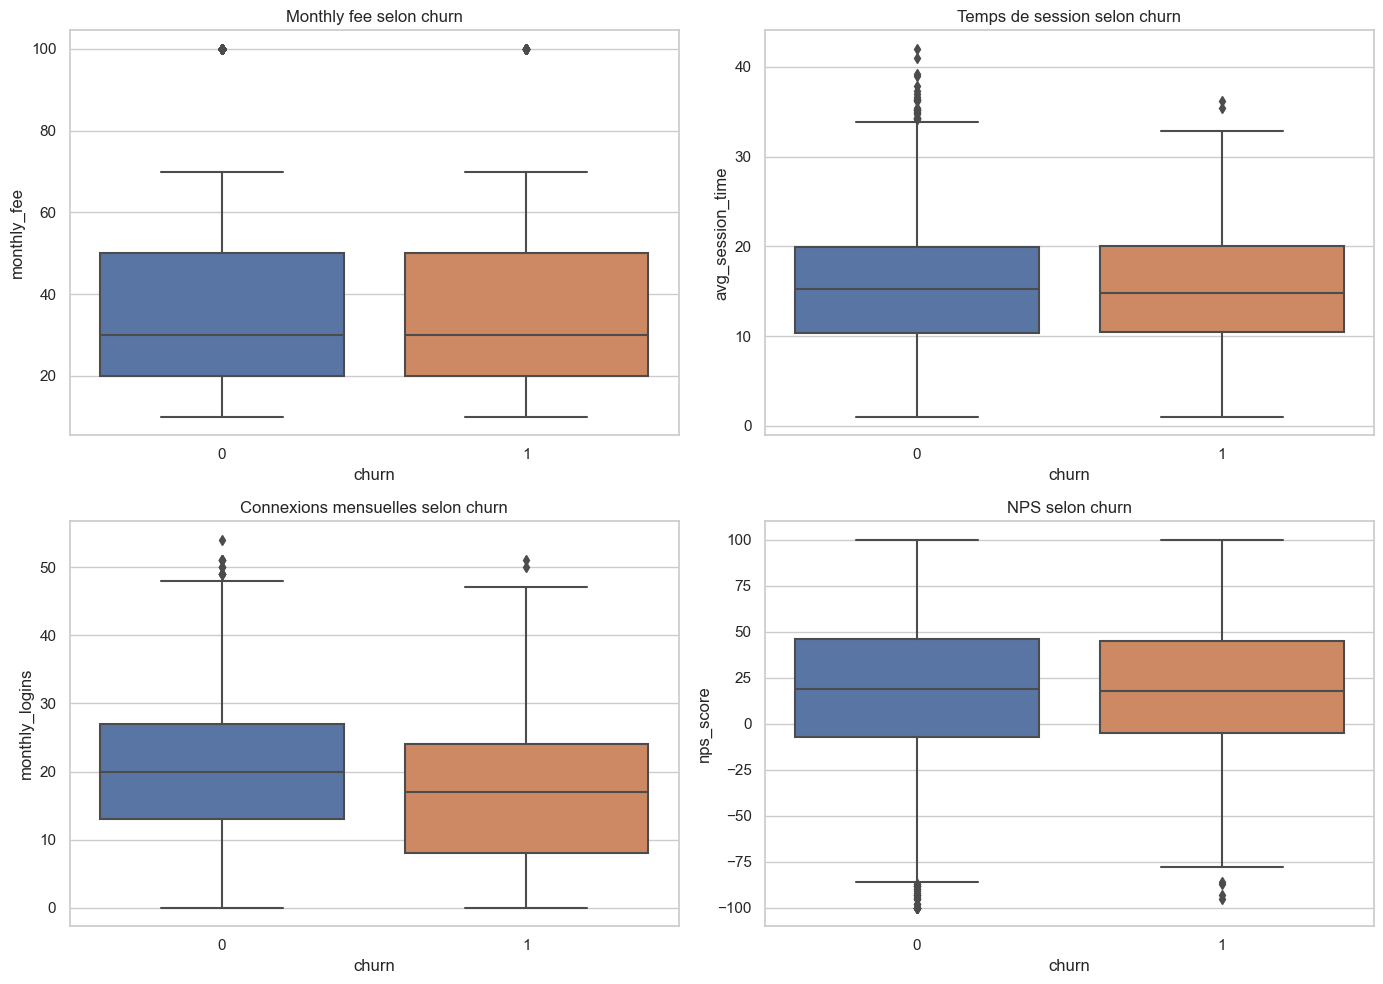

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=model_df, x=TARGET, y="monthly_fee", ax=axes[0, 0])
axes[0, 0].set_title("Monthly fee selon churn")

sns.boxplot(data=model_df, x=TARGET, y="avg_session_time", ax=axes[0, 1])
axes[0, 1].set_title("Temps de session selon churn")

sns.boxplot(data=model_df, x=TARGET, y="monthly_logins", ax=axes[1, 0])
axes[1, 0].set_title("Connexions mensuelles selon churn")

sns.boxplot(data=model_df, x=TARGET, y="nps_score", ax=axes[1, 1])
axes[1, 1].set_title("NPS selon churn")

plt.tight_layout()
plt.show()

## 11. Corrélations entre variables numériques

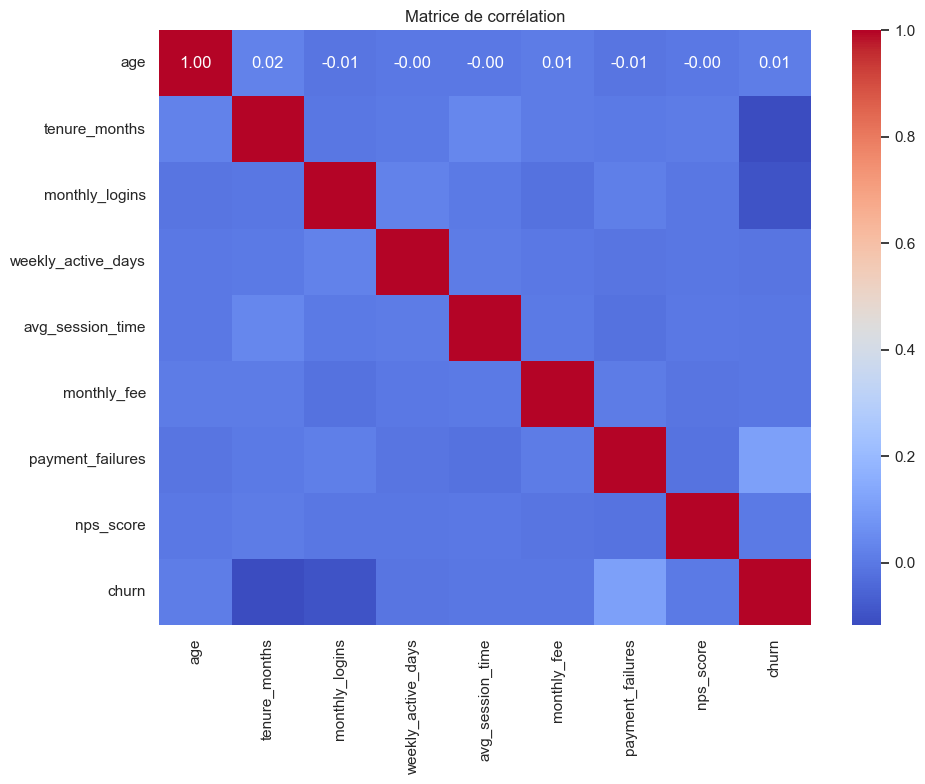

In [84]:
corr_df = model_df[numeric_features + [TARGET]].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

## 12. Tableau de synthèse métier

In [35]:
summary = pd.DataFrame({
    "indicateur": [
        "Taux de churn global",
        "Contrat le plus risqué",
        "NPS moyen des churners",
        "NPS moyen des non churners",
        "Échecs de paiement moyens des churners",
        "Échecs de paiement moyens des non churners",
    ],
    "valeur": [
        f"{model_df[TARGET].mean():.2%}",
        model_df.groupby("contract_type")[TARGET].mean().sort_values(ascending=False).index[0],
        round(model_df.loc[model_df[TARGET] == 1, "nps_score"].mean(), 2),
        round(model_df.loc[model_df[TARGET] == 0, "nps_score"].mean(), 2),
        round(model_df.loc[model_df[TARGET] == 1, "payment_failures"].mean(), 2),
        round(model_df.loc[model_df[TARGET] == 0, "payment_failures"].mean(), 2),
    ]
})
display(summary)

,indicateur,valeur
0,Taux de churn global,10.21%
1,Contrat le plus risqué,Yearly
2,NPS moyen des churners,19.46
3,NPS moyen des non churners,19.07
4,Échecs de paiement moyens des churners,0.74
5,Échecs de paiement moyens des non churners,0.47


## 13. Premières conclusions

Points à commenter dans le rapport :

- la classe `churn=1` est **minoritaire**, ce qui justifie l'usage de métriques comme **PR-AUC** et **Recall** ;
- certaines variables semblent particulièrement liées au churn, par exemple :
  - le **type de contrat**,
  - le **NPS**,
  - les **échecs de paiement**,
  - l'**activité récente** ;
- cette analyse exploratoire permet de justifier les variables retenues dans le modèle final.
